# Experiment 4
## Hill Climbing Algorithm in Python

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Algorithms for Intelligent Systems and Robotics Lab

### Aim
To implement Hill Climbing search in python, use it to maximise a function, see the local maxima problem, fix it using random restart, and then apply the same idea for a robot moving towards a goal.

### Theory
Hill climbing is a **local search**. It does not keep the whole tree like BFS or DFS, it only keeps the current state. At every step it looks at the neighbours and moves to the one which is better according to an objective (or heuristic) function. When no neighbour is better it stops and returns the current state.

Two common versions :
- **Simple hill climbing** takes the first neighbour which is better, without checking the rest.
- **Steepest ascent** checks all the neighbours and takes the best one.

Problems with it :
- **Local maximum** : a peak which is higher than its neighbours but not the highest peak. The algorithm stops there.
- **Plateau** : flat region, all neighbours are equal so it does not know where to go.
- **Ridge** : slope going up in a direction which is not one of the allowed moves.

Random restart hill climbing is the usual fix, run it many times from random starting points and keep the best answer.

### 1. Function to maximise
Starting with a simple one, f(x) = -(x-3)^2 + 9 which has only one peak at x = 3.

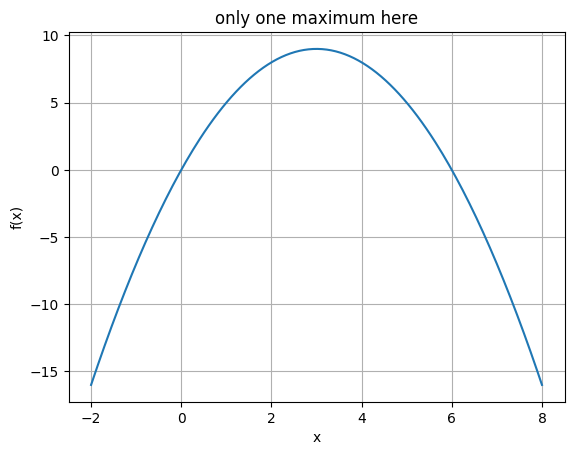

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return -(x - 3)**2 + 9

xs = np.linspace(-2, 8, 200)
plt.plot(xs, f(xs))
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("only one maximum here")
plt.grid(True)
plt.show()

### 2. Simple hill climbing
Neighbours of x are x-step and x+step. First neighbour which is better is accepted.

In [2]:
def simple_hill_climb(f, x, step=0.1, max_iter=1000):
    path = [x]
    for i in range(max_iter):
        moved = False
        for nb in [x - step, x + step]:
            if f(nb) > f(x):
                x = nb
                path.append(x)
                moved = True
                break
        if not moved:
            break
    return x, path

peak, path = simple_hill_climb(f, -1.0)
print("start = -1.0")
print("peak found at x =", round(peak, 3), " f(x) =", round(f(peak), 3))
print("number of moves =", len(path) - 1)

start = -1.0
peak found at x = 3.0  f(x) = 9.0
number of moves = 40


### 3. Steepest ascent
Here all the neighbours are checked and the best one is picked. For this smooth function both give the same peak, only the number of moves can change.

In [18]:
def steepest_ascent(f, x, step=0.1, max_iter=1000):
    path = [x]
    for i in range(max_iter):
        nbs = [x - step, x + step]
        best = max(nbs, key=f)
        if f(best) <= f(x):
            break
        x = best
        path.append(x)
    return x, path

peak2, path2 = steepest_ascent(f, -1.0)
print("peak =", round(peak2, 3), " moves =", len(path2) - 1)

peak = 3.0  moves = 40


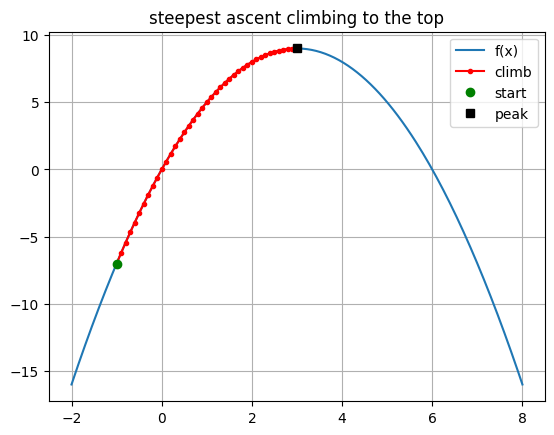

In [4]:
plt.plot(xs, f(xs), label="f(x)")
plt.plot(path2, [f(p) for p in path2], 'r.-', label="climb")
plt.plot(path2[0], f(path2[0]), 'go', label="start")
plt.plot(path2[-1], f(path2[-1]), 'ks', label="peak")
plt.legend()
plt.title("steepest ascent climbing to the top")
plt.grid(True)
plt.show()

### 4. The local maxima problem
Now a function with many peaks, f(x) = 2 sin(x) + sin(2.5x) on 0 to 10. Depending on where we start, the algorithm stops on a diffrent peak.

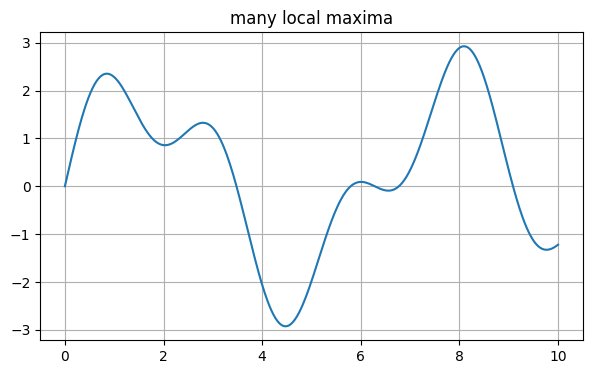

real global maximum is around x = 8.1  value = 2.925


In [5]:
def g(x):
    return 2*np.sin(x) + np.sin(2.5*x)

xg = np.linspace(0, 10, 500)
plt.figure(figsize=(7,4))
plt.plot(xg, g(xg))
plt.title("many local maxima")
plt.grid(True)
plt.show()

print("real global maximum is around x =", round(xg[g(xg).argmax()], 2), " value =", round(g(xg).max(), 3))

In [6]:
for s in [0.5, 3.0, 5.0, 8.0]:
    p, _ = steepest_ascent(g, s, step=0.05)
    print("start", s, "  stopped at x =", round(p, 3), "  value =", round(g(p), 3))

start 0.5   stopped at x = 0.85   value = 2.353
start 3.0   stopped at x = 2.8   value = 1.327
start 5.0   stopped at x = 6.0   value = 0.091
start 8.0   stopped at x = 8.1   value = 2.925


So only the start at 8.0 gave the real answer. From 0.5 and 3.0 and 5.0 it got stuck on smaller peaks, it cannot see beyond its neighbours.

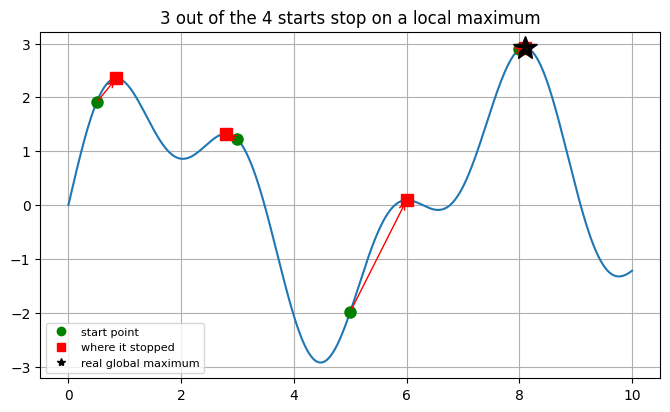

In [8]:
plt.figure(figsize=(8,4.5))
plt.plot(xg, g(xg))

# showing all the four starting points together
for s in [0.5, 3.0, 5.0, 8.0]:
    stop, _ = steepest_ascent(g, s, step=0.05)
    plt.plot(s, g(s), 'go', markersize=8)
    plt.plot(stop, g(stop), 'rs', markersize=9)
    plt.annotate("", xy=(stop, g(stop)), xytext=(s, g(s)),
                 arrowprops=dict(arrowstyle="->", color='red'))

gx = xg[g(xg).argmax()]
plt.plot(gx, g(gx), 'k*', markersize=18)

plt.plot([], [], 'go', label="start point")
plt.plot([], [], 'rs', label="where it stopped")
plt.plot([], [], 'k*', label="real global maximum")
plt.legend(loc='lower left', fontsize=8)
plt.title("3 out of the 4 starts stop on a local maximum")
plt.grid(True)
plt.show()

### 5. Random restart hill climbing
Run the same climbing many times from random points and keep the best result.

In [9]:
import random
random.seed(1)

def random_restart(f, low, high, tries=10, step=0.05):
    best_x = None
    peaks = []                     # keeping every try so that i can plot them after

    for i in range(tries):
        s = random.uniform(low, high)
        x, _ = steepest_ascent(f, s, step=step)
        peaks.append([s, x])
        print("try", i, ": start", round(s,2), " peak", round(x,3), " value", round(f(x),3))
        if best_x is None or f(x) > f(best_x):
            best_x = x

    return best_x, peaks

best, peaks = random_restart(g, 0, 10, tries=8)
print()
print("best out of all tries : x =", round(best,3), " value =", round(g(best),3))

try 0 : start 1.34  peak 0.844  value 2.353
try 1 : start 8.47  peak 8.074  value 2.924
try 2 : start 7.64  peak 8.088  value 2.925
try 3 : start 2.55  peak 2.801  value 1.327
try 4 : start 4.95  peak 6.004  value 0.092
try 5 : start 4.49  peak 5.995  value 0.091
try 6 : start 6.52  peak 6.016  value 0.091
try 7 : start 7.89  peak 8.087  value 2.925

best out of all tries : x = 8.088  value = 2.925


Plotting all the 8 tries together. Most of them land on the smaller peaks but one of them reaches the real top.

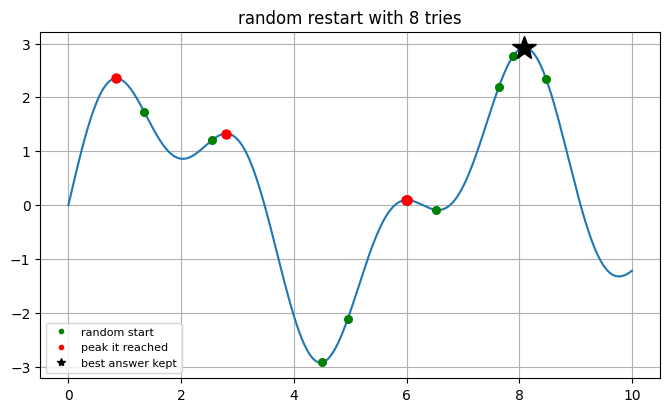

In [10]:
plt.figure(figsize=(8,4.5))
plt.plot(xg, g(xg))

for s, x in peaks:
    plt.plot(s, g(s), 'g.', markersize=11)
    plt.plot(x, g(x), 'r.', markersize=13)

plt.plot(best, g(best), 'k*', markersize=18)
plt.plot([], [], 'g.', label="random start")
plt.plot([], [], 'r.', label="peak it reached")
plt.plot([], [], 'k*', label="best answer kept")
plt.legend(loc='lower left', fontsize=8)
plt.title("random restart with 8 tries")
plt.grid(True)
plt.show()

### 6. Hill climbing for a robot on a grid
Now the same algorithm for path planning. State is the cell of the robot, neighbours are the 4 free cells around it, and the heuristic is the manhattan distance to the goal. Since we want to go to the smallest distance, here it is hill **descent**, but the algorithm is exactly same, only the comparison sign changes.

The goal is kept inside a room which has only one door at the bottom.

In [11]:
grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0]
])

start = (0, 0)
goal  = (4, 4)
print(grid)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 1 0]
 [0 0 1 0 0 0 1 0]
 [0 0 1 0 0 0 1 0]
 [0 0 1 1 0 1 1 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [12]:
def h(cell):
    return abs(cell[0] - goal[0]) + abs(cell[1] - goal[1])

def moves(grid, cell):
    rows, cols = grid.shape
    r, c = cell
    out = []
    for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == 0:
            out.append((nr, nc))
    return out

print("h at start =", h(start))
print("moves from start :", moves(grid, start))

h at start = 8
moves from start : [(1, 0), (0, 1)]


In [13]:
def hill_climb_robot(grid, start, goal):
    cur = start
    path = [cur]

    while cur != goal:
        nbs = moves(grid, cur)
        best = min(nbs, key=h)
        if h(best) >= h(cur):
            return path, False
        cur = best
        path.append(cur)

    return path, True

robot_path, reached = hill_climb_robot(grid, start, goal)
print("path :", robot_path)
print("goal reached :", reached)
print("stopped at", robot_path[-1], "with h =", h(robot_path[-1]))

path : [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1)]
goal reached : False
stopped at (4, 1) with h = 3


It stopped at (4,1). From there every free neighbour has distance 4 which is more than 3, and the wall is in front, so no move looks better. This is exactly the local maximum problem, in the grid form it is called a local minimum of the heuristic.

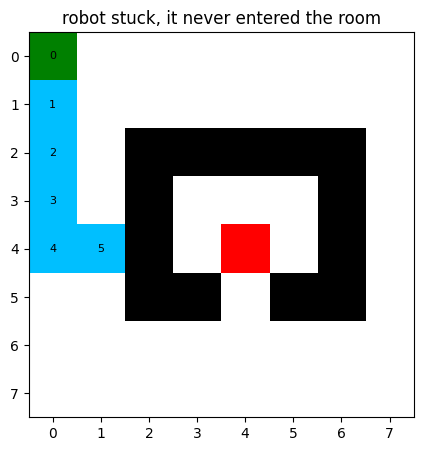

In [14]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['white', 'black', 'deepskyblue', 'green', 'red'])

img = grid.copy()
for c in robot_path:
    img[c] = 2
img[start] = 3
img[goal] = 4

plt.figure(figsize=(5,5))
plt.imshow(img, cmap=cmap, vmin=0, vmax=4)
for i, c in enumerate(robot_path):
    plt.text(c[1], c[0], str(i), ha='center', va='center', fontsize=8)
plt.title("robot stuck, it never entered the room")
plt.xticks(range(8)); plt.yticks(range(8))
plt.show()

For comparing, BFS from experiment 3 does reach the goal on the same map because it does not care about the heuristic, it simply expands everything.

In [15]:
from collections import deque

def bfs_path(grid, start, goal):
    q = deque([[start]])
    seen = {start}
    while q:
        path = q.popleft()
        if path[-1] == goal:
            return path
        for m in moves(grid, path[-1]):
            if m not in seen:
                seen.add(m)
                q.append(path + [m])
    return None

bp = bfs_path(grid, start, goal)
print("BFS reached the goal in", len(bp) - 1, "steps")
print(bp)

BFS reached the goal in 12 steps
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (5, 4), (4, 4)]


### 7. Result

| | Hill climbing | BFS / DFS |
|---|---|---|
| Keeps | Only current state | Whole frontier |
| Memory | Very less | High |
| Uses heuristic | Yes | No |
| Gives best answer | Not always | BFS gives shortest path |
| Gets stuck | Local maxima, plateau, ridge | No |

**Observation :** on the single peak function hill climbing reached the top easily. On the multi peak function it stopped at a local maximum for 3 out of the 4 starting points, and random restart with 8 tries found the global maximum. On the grid map the robot moved 5 steps and then got stuck at (4,1) because of the wall, while BFS reached the same goal in 12 steps.

**Result :** hill climbing is implemented in python and tested on functions and on a grid map. It is fast and takes very little memory because it stores only one state, but it is not complete and not optimal, it can stop on a local maximum. Random restart improves it a lot. For robot path planning a plain heuristic descent is not safe when obstacles are there, that is why A* is used which mixes the heuristic with the actual cost.

### 8. Conclusion
Hill climbing was implemented and tested on a continuous function as well as on a discrete grid environment, and its behaviour was studied in both cases.

The algorithm is simple to implement and needs a very small amount of memory because only the current state is stored at any time. On a function having a single peak it converged to the optimum without any difficulty.

The experiment also brings out the two main limitations of the method. On the multimodal function the search terminated at a local maximum in three out of the four trials, since a move is accepted only when an immediate neighbour is better than the current state. The same limitation appeared on the grid map in the form of a local minimum of the heuristic, where an obstacle lying between the robot and the goal stopped the search after five moves even though a valid path was available through the door of the room.

Random restart was found to be an effective remedy and it recovered the global maximum within eight trials, but it improves the chance of success only by repetition and does not give any guarantee of optimality.

It is therefore concluded that hill climbing is suitable for problems where speed and low memory usage are more important than the quality of the solution, and that for reliable robot path planning in the presence of obstacles an informed search such as A*, which considers the actual path cost along with the heuristic, is required.